<a href="https://colab.research.google.com/github/PihuCodeTech/Aircraft-Engine-RUL-Prediction/blob/main/notebooks/DeepBiLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install optuna -q
print("Optuna ready.")

Optuna ready.


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Deep BiLSTM — SNIPPET 1: PREPROCESSING + ARCHITECTURE
# Paper: Wang et al., 2018 PHM Conference
# "Remaining Useful Life Estimation in Prognostics Using Deep BiLSTM"
# Unchanged from base implementation — foundation for all later snippets.
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np, random, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, LSTM, Dropout, Bidirectional,
    LayerNormalization, MultiHeadAttention, Add,
    GlobalAveragePooling1D, BatchNormalization
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings; warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

DATA_PATH = '/content/'
SEQ_LEN   = 40

DATASET_CONFIG = {
    'FD001': {'rul_threshold': 125},
    'FD002': {'rul_threshold': 125},
    'FD003': {'rul_threshold': 125},
    'FD004': {'rul_threshold': 125},
}

FEATURES_14 = [
    's2','s3','s4','s7','s8','s9',
    's11','s12','s13','s14','s15','s17','s20','s21'
]
FEATURES_25 = ['cycle','op1','op2','op3'] + [f's{i}' for i in range(1, 22)]

ACTIVE_FEATURES = FEATURES_25
N_FEATURES      = len(ACTIVE_FEATURES)

HP_DEFAULT = {
    'bilstm_units'    : [64, 32],
    'n_bilstm_layers' : 2,
    'dense_units'     : [16, 8],
    'dropout'         : 0.2,
    'recurrent_dropout': 0.0,
    'l2_reg'          : 1e-4,
    'lr'              : 1e-3,
    'batch_size'      : 64,
    'epochs'          : 300,
    'patience_es'     : 30,
    'patience_lr'     : 10,
    'lr_factor'       : 0.5,
    'min_lr'          : 1e-7,
    'clipnorm'        : 1.0,
    'weight_decay'    : 0.0,
    'optimizer'       : 'adam',
    'use_attention'   : True,
    'attn_heads'      : 4,
    'attn_key_dim'    : 32,
}

# ── Data loading ────────────────────────────────────────────────────────────
def load_data(dataset):
    cols     = ['id','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]
    train_df = pd.read_csv(f"{DATA_PATH}train_{dataset}.txt",
                           sep=r"\s+", header=None)
    train_df.columns = cols
    test_df  = pd.read_csv(f"{DATA_PATH}test_{dataset}.txt",
                           sep=r"\s+", header=None)
    test_df.columns  = cols
    y_test   = pd.read_csv(f"{DATA_PATH}RUL_{dataset}.txt",
                           header=None).values.flatten()
    return train_df, test_df, y_test

# ── Preprocessing: MinMax [0,1] ───────────────────────────────────────────────
def preprocess(train_df, test_df, dataset, feature_cols=None):
    if feature_cols is None:
        feature_cols = ACTIVE_FEATURES
    cfg           = DATASET_CONFIG[dataset]
    max_c         = train_df.groupby('id')['cycle'].max().reset_index()
    max_c.columns = ['id','max_cycle']
    train_df      = train_df.merge(max_c, on='id')
    train_df['RUL'] = (train_df['max_cycle'] -
                       train_df['cycle']).clip(upper=cfg['rul_threshold'])
    train_df.drop(columns=['max_cycle'], inplace=True)
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    test_df[feature_cols]  = scaler.transform(test_df[feature_cols])
    return train_df, test_df, feature_cols, scaler

# ── Sequence generation ───────────────────────────────────────────────────────
def create_sequences(df, feature_cols, seq_len):
    Xs, ys = [], []
    for eid in df['id'].unique():
        d = df[df['id'] == eid][feature_cols + ['RUL']].values
        for i in range(len(d) - seq_len):
            Xs.append(d[i:i+seq_len, :-1])
            ys.append(d[i+seq_len, -1])
    return (np.array(Xs, dtype=np.float32),
            np.array(ys, dtype=np.float32))

def create_test_sequences(test_df, feature_cols, seq_len):
    Xs = []
    nf = len(feature_cols)
    for eid in test_df['id'].unique():
        d = test_df[test_df['id'] == eid][feature_cols].values
        if len(d) < seq_len:
            pad = np.zeros((seq_len - len(d), nf), dtype=np.float32)
            d   = np.vstack([pad, d])
        else:
            d = d[-seq_len:]
        Xs.append(d)
    return np.array(Xs, dtype=np.float32)

# ── Metrics ────────────────────────────────────────────────────────────────
def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    return float(np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)))

def report_metrics(name, true, pred):
    mse  = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(true, pred)
    nasa = nasa_score(true, pred)
    print(f"  {name:42s} RMSE={rmse:.3f}  MAE={mae:.3f}  NASA={nasa:.1f}")
    return rmse, mae, mse, nasa

# ── Custom RMSE loss ───────────────────────────────────────────────────────────
def rmse_loss(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)) + 1e-8)

# ── Optimizer builder ─────────────────────────────────────────────────────────
def build_optimizer(hp):
    lr       = hp['lr']
    clip     = hp.get('clipnorm', 1.0)
    wd       = hp.get('weight_decay', 0.0)
    opt_name = hp.get('optimizer', 'adam').lower()
    if opt_name == 'adam':
        if wd > 0:
            from tensorflow.keras.optimizers import AdamW
            return AdamW(learning_rate=lr, weight_decay=wd, clipnorm=clip)
        return Adam(learning_rate=lr, clipnorm=clip)
    elif opt_name == 'rmsprop':
        return RMSprop(learning_rate=lr, clipnorm=clip)
    elif opt_name == 'sgd':
        return SGD(learning_rate=lr, momentum=0.9, clipnorm=clip)
    else:
        return Adam(learning_rate=lr, clipnorm=clip)

# ── Deep BiLSTM model ─────────────────────────────────────────────────────────
def build_bilstm(seq_len, n_features, hp):
    reg     = l2(hp['l2_reg']) if hp.get('l2_reg', 0) > 0 else None
    units   = hp['bilstm_units']
    dense_u = hp['dense_units']
    dr      = hp['dropout']
    rdr     = hp.get('recurrent_dropout', 0.0)
    n_lay   = hp.get('n_bilstm_layers', len(units))

    inputs = Input(shape=(seq_len, n_features), name='input')
    x      = inputs

    for i in range(n_lay):
        u          = units[i] if i < len(units) else units[-1]
        return_seq = (i < n_lay - 1) or hp.get('use_attention', False)
        x = Bidirectional(
            LSTM(u, return_sequences=return_seq,
                 recurrent_dropout=rdr,
                 kernel_regularizer=reg,
                 recurrent_regularizer=reg),
            name=f'bilstm_{i+1}'
        )(x)
        x = Dropout(dr, name=f'drop_bilstm_{i+1}')(x)

    if hp.get('use_attention', False):
        nh   = hp.get('attn_heads', 4)
        kd   = hp.get('attn_key_dim', 32)
        attn = MultiHeadAttention(num_heads=nh, key_dim=kd,
                                   dropout=dr/2, name='mha')(x, x)
        x    = LayerNormalization(name='ln_attn')(Add(name='res_attn')([x, attn]))
        x    = GlobalAveragePooling1D(name='gap')(x)

    for j, du in enumerate(dense_u):
        x = Dense(du, activation='relu',
                  kernel_regularizer=reg, name=f'fc_{j+1}')(x)
        x = Dropout(dr, name=f'drop_fc_{j+1}')(x)

    output = Dense(1, activation='linear', name='rul_output')(x)
    model  = Model(inputs, output, name='DeepBiLSTM')
    model.compile(optimizer=build_optimizer(hp),
                  loss=rmse_loss, metrics=['mae'])
    return model

# ── Visualization ─────────────────────────────────────────────────────────────
def plot_loss(h, ds):
    plt.figure(figsize=(10,4))
    plt.plot(h.history['loss'],     label='Train RMSE')
    plt.plot(h.history['val_loss'], label='Val RMSE')
    plt.title(f'Deep BiLSTM — Loss vs Epoch ({ds})')
    plt.xlabel('Epoch'); plt.ylabel('RMSE Loss')
    plt.legend(); plt.grid(); plt.show()

def plot_predictions(y_test, pred, ds):
    plt.figure(figsize=(14,4))
    plt.plot(y_test, label='Actual RUL',  color='black',      lw=2)
    plt.plot(pred,   label='BiLSTM Pred', color='darkorange', lw=1.5, alpha=0.85)
    plt.title(f'Actual vs Predicted RUL — Deep BiLSTM ({ds})')
    plt.xlabel('Engine Index'); plt.ylabel('RUL')
    plt.legend(); plt.grid(); plt.show()

def plot_residuals(y_test, pred, ds):
    res = y_test - pred
    plt.figure(figsize=(10,4))
    plt.scatter(range(len(res)), res, alpha=0.5, s=15, color='darkorange')
    plt.axhline(0, color='black', ls='--', lw=1.5)
    plt.title(f'Residuals — Deep BiLSTM ({ds})')
    plt.xlabel('Engine Index'); plt.ylabel('Actual − Predicted')
    plt.grid(); plt.show()

def plot_rmse_bar(results_dict, title='Deep BiLSTM — Test RMSE'):
    ds_list = list(results_dict.keys())
    vals    = [results_dict[ds]['rmse'] for ds in ds_list]
    plt.figure(figsize=(8,5))
    bars = plt.bar(ds_list, vals, color='darkorange', edgecolor='white', alpha=0.85)
    plt.bar_label(bars, fmt='%.3f', padding=3)
    plt.title(title); plt.ylabel('Test RMSE')
    plt.grid(axis='y'); plt.show()

def plot_rul_dist(train_df, ds):
    plt.figure(figsize=(10,4))
    plt.hist(train_df['RUL'], bins=40, color='darkorange', edgecolor='white', alpha=0.8)
    plt.title(f'RUL Distribution — {ds}')
    plt.xlabel('RUL'); plt.ylabel('Frequency'); plt.grid(); plt.show()

def plot_baseline_comparison(paper_results, our_results):
    datasets   = ['FD001','FD002','FD003','FD004']
    paper_rmse = [paper_results.get(ds, 0) for ds in datasets]
    our_rmse   = [our_results.get(ds, {}).get('rmse', 0) for ds in datasets]
    x = np.arange(len(datasets)); w = 0.35
    plt.figure(figsize=(10,5))
    b1 = plt.bar(x-w/2, paper_rmse, w, label='Paper (BiLSTM 2018)', color='steelblue')
    b2 = plt.bar(x+w/2, our_rmse,   w, label='Ours',                color='darkorange')
    plt.bar_label(b1, fmt='%.2f', padding=3, fontsize=9)
    plt.bar_label(b2, fmt='%.2f', padding=3, fontsize=9)
    plt.xticks(x, datasets)
    plt.title('Deep BiLSTM: Paper Results vs Ours')
    plt.ylabel('Test RMSE'); plt.legend(); plt.grid(axis='y'); plt.show()

# ── Verification ──────────────────────────────────────────────────────────────
print("="*60)
print("  DEEP BiLSTM ARCHITECTURE (Wang et al. 2018)")
print("="*60)
_m = build_bilstm(SEQ_LEN, N_FEATURES, HP_DEFAULT)
_m.summary()
print(f"\n  Input  : (B, {SEQ_LEN}, {N_FEATURES})")
print(f"  BLSTM1 : (B, {SEQ_LEN}, {HP_DEFAULT['bilstm_units'][0]*2})")
print(f"  BLSTM2 : (B, {HP_DEFAULT['bilstm_units'][1]*2})")
print(f"  FC1    : (B, {HP_DEFAULT['dense_units'][0]})")
print(f"  FC2    : (B, {HP_DEFAULT['dense_units'][1]})")
print(f"  Output : (B, 1)")
del _m

print(f"\n  Dataset check:")
for ds in ['FD001','FD002','FD003','FD004']:
    tr, te, y = load_data(ds)
    print(f"    {ds}: train={tr.shape}  test={te.shape}  y_test={y.shape}")
print("\n  Snippet 1 ready.\n")

  DEEP BiLSTM ARCHITECTURE (Wang et al. 2018)


Model: "DeepBiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 40, 25)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 40, 128)   │     46,080 │ input[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_bilstm_1       │ (None, 40, 128)   │          0 │ bilstm_1[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 40, 64)    │     41,216 │ drop_bilstm_1[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_bilstm_2       │ (None, 40, 64)    │          0 │ bilstm_2[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha                 │ (None, 40, 64)    │     33,216 │ drop_bilstm_2[0]… │
│ (MultiHeadAttentio… │                   │            │ drop_bilstm_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_attn (Add)      │ (None, 40, 64)    │          0 │ drop_bilstm_2[0]… │
│                     │                   │            │ mha[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_attn             │ (None, 40, 64)    │        128 │ res_attn[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 64)        │          0 │ ln_attn[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_1 (Dense)        │ (None, 16)        │      1,040 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_fc_1 (Dropout) │ (None, 16)        │          0 │ fc_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_2 (Dense)        │ (None, 8)         │        136 │ drop_fc_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_fc_2 (Dropout) │ (None, 8)         │          0 │ fc_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rul_output (Dense)  │ (None, 1)         │          9 │ drop_fc_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 121,825 (475.88 KB)

 Trainable params: 121,825 (475.88 KB)

 Non-trainable params: 0 (0.00 B)


  Input  : (B, 40, 25)
  BLSTM1 : (B, 40, 128)
  BLSTM2 : (B, 64)
  FC1    : (B, 16)
  FC2    : (B, 8)
  Output : (B, 1)

  Dataset check:
    FD001: train=(20631, 26)  test=(13096, 26)  y_test=(100,)
    FD002: train=(53759, 26)  test=(33991, 26)  y_test=(259,)
    FD003: train=(24720, 26)  test=(16596, 26)  y_test=(100,)
    FD004: train=(61249, 26)  test=(41214, 26)  y_test=(248,)

  Snippet 1 ready.




████████████████████████████████████████████████████████████
  DEEP BiLSTM BASELINE  —  Wang et al. 2018
  Architecture: BiLSTM(64)→BiLSTM(32)→FC(16)→FC(8)→FC(1)
  Loss: RMSE | Norm: MinMax[0,1] | epochs=300
████████████████████████████████████████████████████████████

───────────────────────────────────────────────────────
  DATASET: FD001
───────────────────────────────────────────────────────


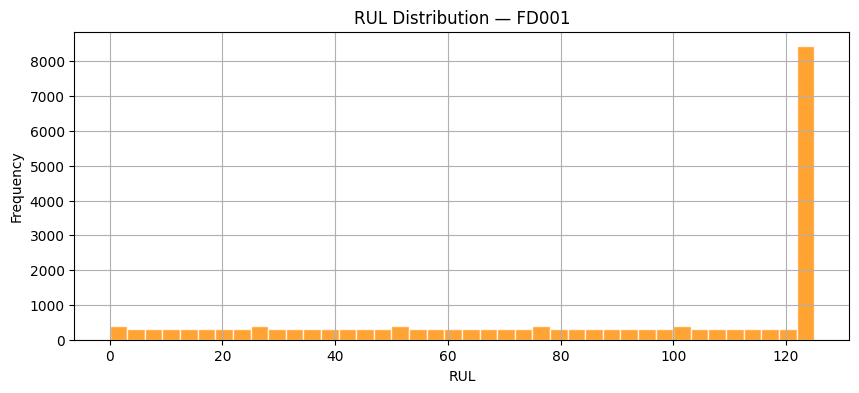

  Train:(13361, 40, 25) Val:(3270, 40, 25) Test:(100, 40, 25)
  HP: units=[64, 32] dense=[16, 8] dr=0.20 lr=1.0e-03 bs=64 attn=True

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 42: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

  Val  ↓
  Deep BiLSTM                                RMSE=11.773  MAE=8.955  NASA=5680.0
  Test ↓
  Deep BiLSTM                                RMSE=14.241  MAE=9.956  NASA=265.3
  vs Paper: 13.65  →  +0.591


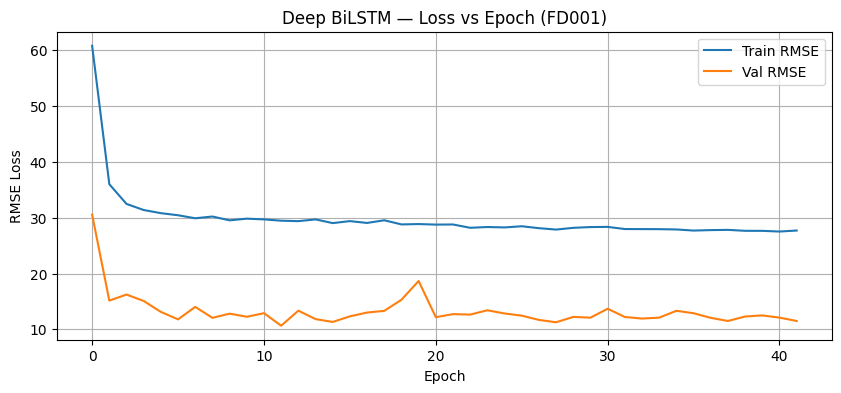

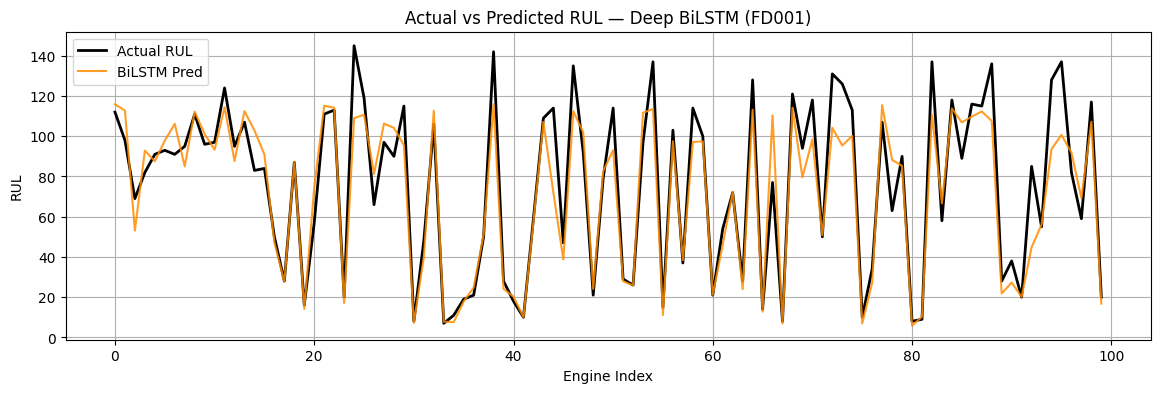

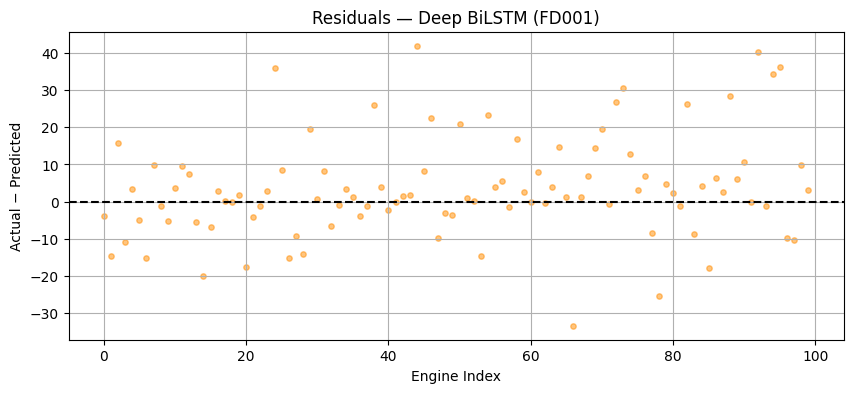


───────────────────────────────────────────────────────
  DATASET: FD002
───────────────────────────────────────────────────────


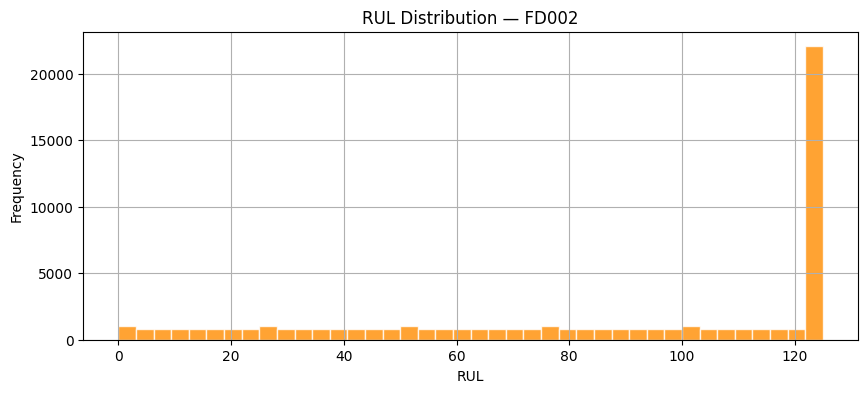

  Train:(35144, 40, 25) Val:(8215, 40, 25) Test:(259, 40, 25)
  HP: units=[64, 32] dense=[16, 8] dr=0.20 lr=1.0e-03 bs=64 attn=True

Epoch 41: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 58: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 73: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 83: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 93: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

  Val  ↓
  Deep BiLSTM                                RMSE=15.812  MAE=12.473  NASA=37929.3
  Test ↓
  Deep BiLSTM                                RMSE=30.977  MAE=21.218  NASA=17568.5
  vs Paper: 23.18  →  +7.797


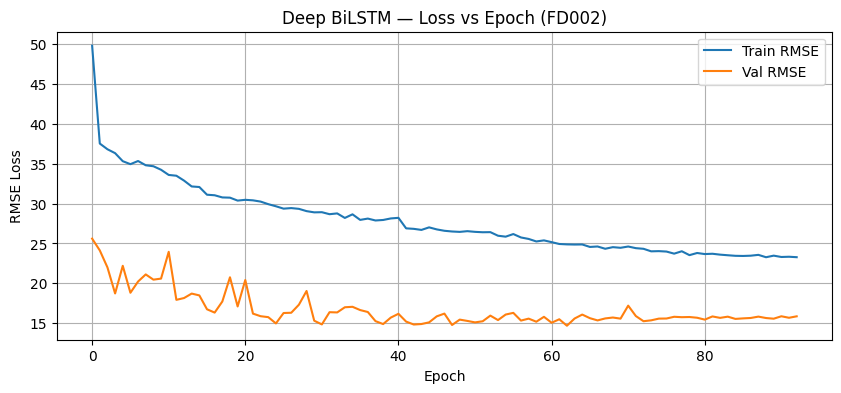

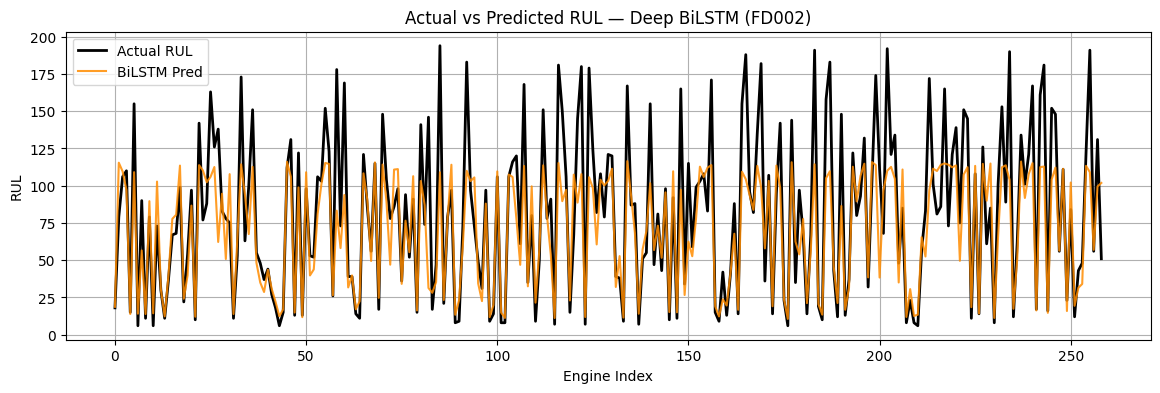

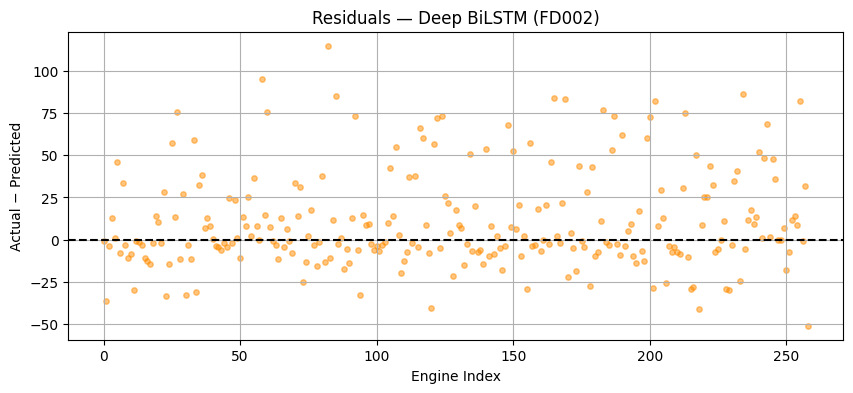


───────────────────────────────────────────────────────
  DATASET: FD003
───────────────────────────────────────────────────────


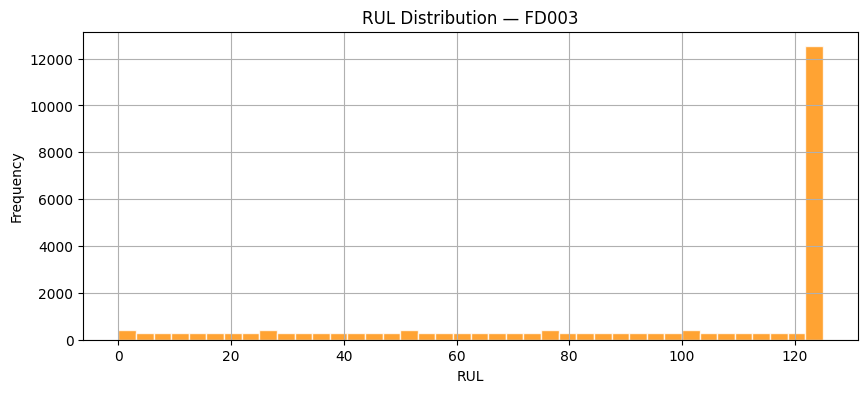

  Train:(16812, 40, 25) Val:(3908, 40, 25) Test:(100, 40, 25)
  HP: units=[64, 32] dense=[16, 8] dr=0.20 lr=1.0e-03 bs=64 attn=True

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 35: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 45: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

  Val  ↓
  Deep BiLSTM                                RMSE=11.921  MAE=9.845  NASA=7738.6
  Test ↓
  Deep BiLSTM                                RMSE=16.917  MAE=12.823  NASA=444.1
  vs Paper: 13.74  →  +3.177


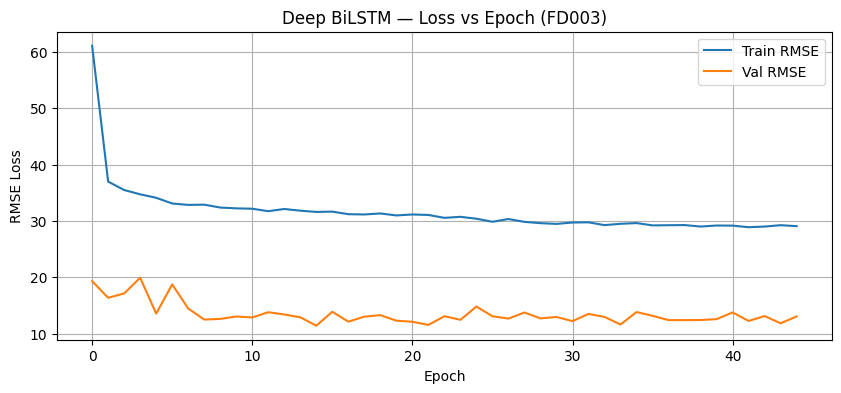

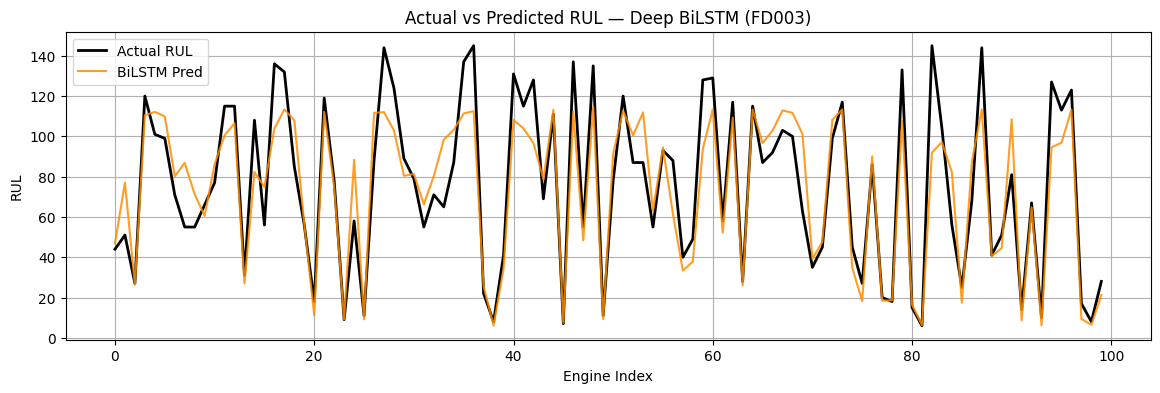

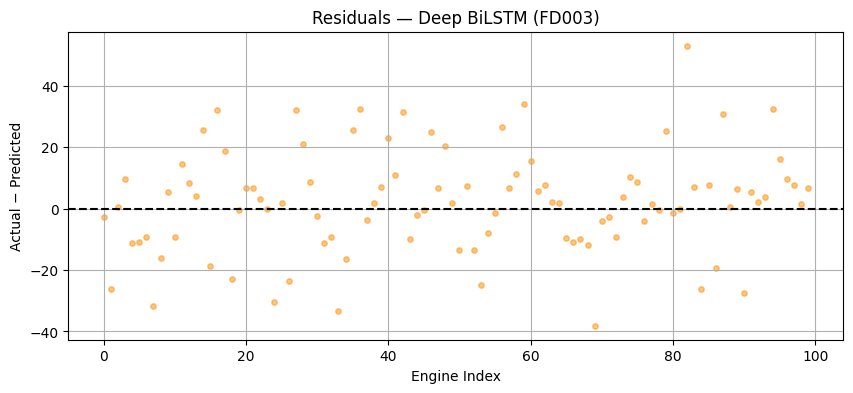


───────────────────────────────────────────────────────
  DATASET: FD004
───────────────────────────────────────────────────────


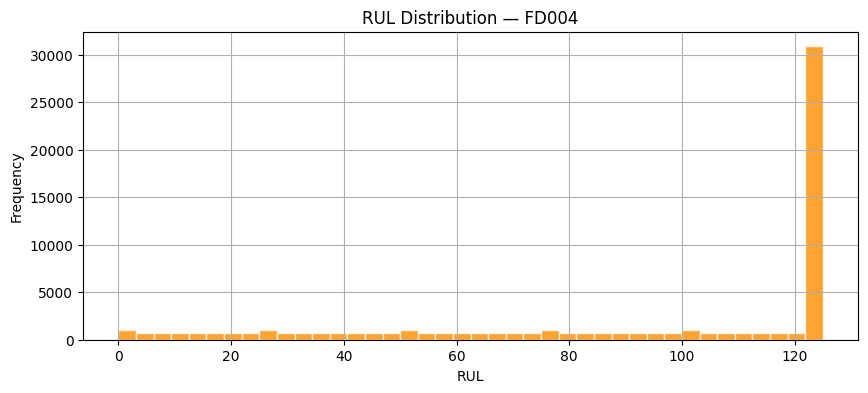

  Train:(41334, 40, 25) Val:(9955, 40, 25) Test:(248, 40, 25)
  HP: units=[64, 32] dense=[16, 8] dr=0.20 lr=1.0e-03 bs=64 attn=True

Epoch 40: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 62: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 72: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 82: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

  Val  ↓
  Deep BiLSTM                                RMSE=22.766  MAE=17.805  NASA=162852.6
  Test ↓
  Deep BiLSTM                                RMSE=32.818  MAE=26.196  NASA=9398.6
  vs Paper: 24.86  →  +7.958


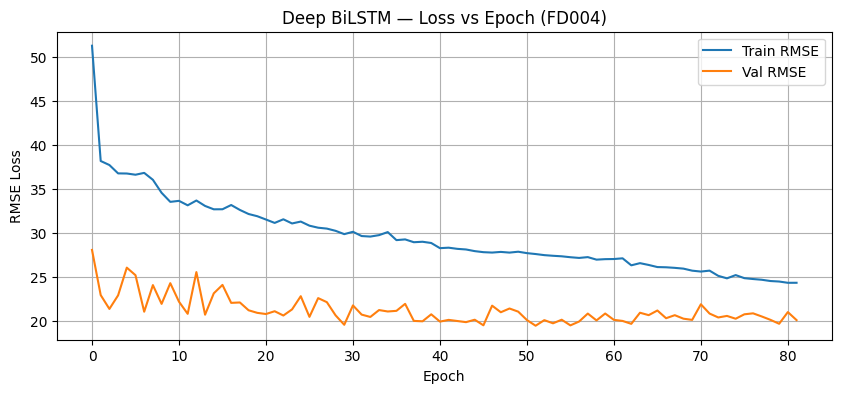

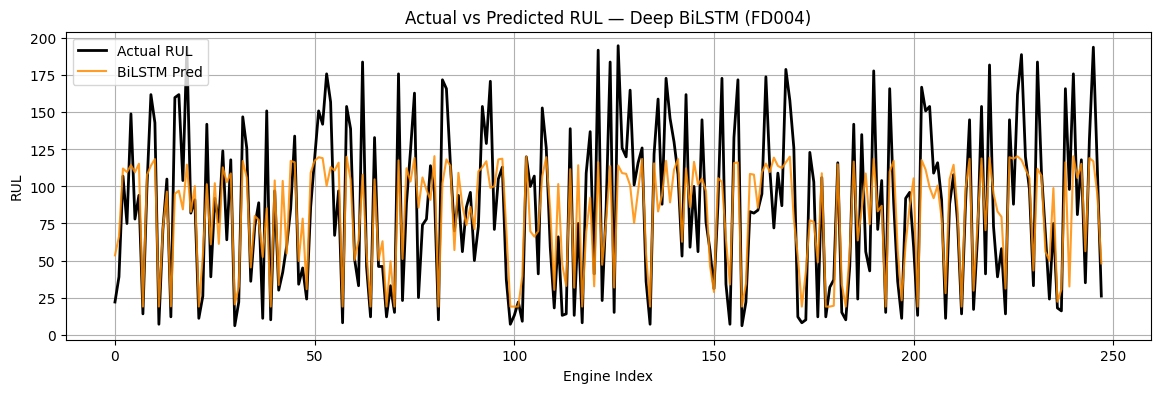

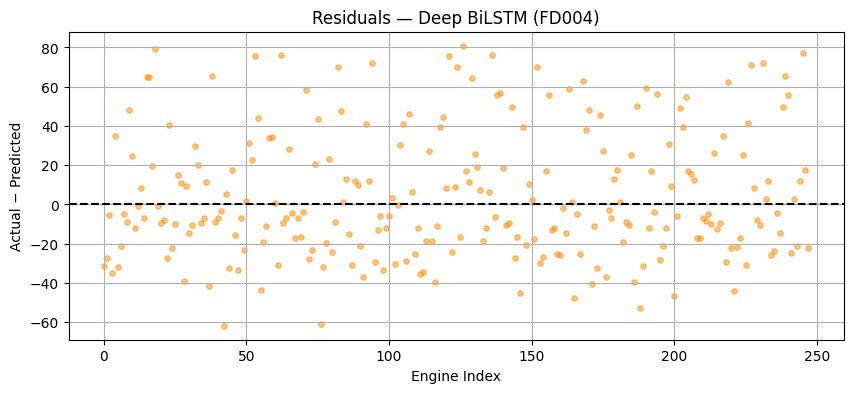


══════════════════════════════════════════════════════════════════════
  DEEP BiLSTM BASELINE RESULTS
══════════════════════════════════════════════════════════════════════
  Dataset        RMSE      MAE       NASA    Paper   vs Paper
  ────────── ──────── ──────── ────────── ──────── ──────────
  FD001        14.241    9.956      265.3    13.65     +0.591
  FD002        30.977   21.218    17568.5    23.18     +7.797
  FD003        16.917   12.823      444.1    13.74     +3.177
  FD004        32.818   26.196     9398.6    24.86     +7.958

  Average RMSE: 23.738


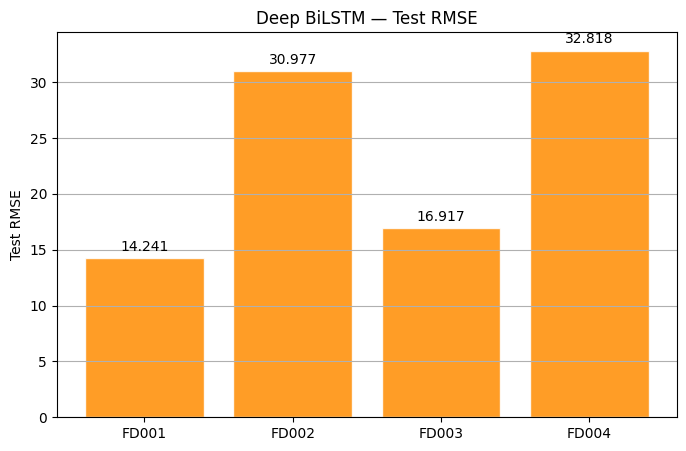

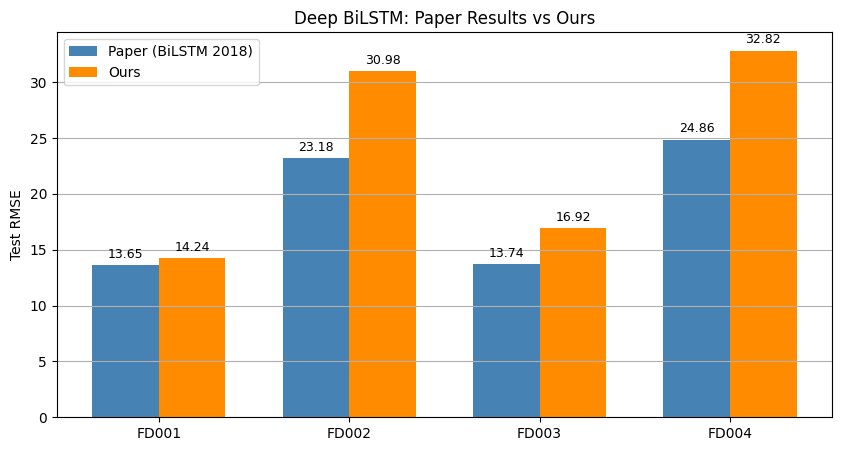

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Deep BiLSTM — SNIPPET 2: TRAINING + EVALUATION + BASELINE (PHASE 0)
# MODIFIED: run_random_search, run_bayesian_opt, quick_val_rmse, and Phase 3
# stubs have been REMOVED — replaced by the subprocess-isolated, warm-started
# search in Snippets 3–5.
# ══════════════════════════════════════════════════════════════════════════════
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Paper results for comparison (Table II)
PAPER_RESULTS = {
    'FD001': 13.65,
    'FD002': 23.18,
    'FD003': 13.74,
    'FD004': 24.86,
}

DATASETS = ['FD001','FD002','FD003','FD004']

# ── Callbacks ────────────────────────────────────────────────────────────────
def get_callbacks(hp):
    return [
        EarlyStopping(monitor='val_loss', patience=hp['patience_es'],
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=hp['lr_factor'],
                          patience=hp['patience_lr'],
                          min_lr=hp['min_lr'], verbose=1)
    ]

# ── Train and evaluate (full pipeline) ────────────────────────────────────────
def train_and_evaluate(dataset, hp, feature_cols=None, show_plots=True):
    np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

    if feature_cols is None:
        feature_cols = ACTIVE_FEATURES

    train_raw, test_raw, y_test = load_data(dataset)
    train_df, test_df, feat, _ = preprocess(
        train_raw.copy(), test_raw.copy(), dataset, feature_cols)

    if show_plots:
        plot_rul_dist(train_df, dataset)

    eids             = train_df['id'].unique()
    tr_e, val_e      = train_test_split(eids, test_size=0.2, random_state=SEED)
    X_train, y_train = create_sequences(train_df[train_df['id'].isin(tr_e)], feat, SEQ_LEN)
    X_val,   y_val   = create_sequences(train_df[train_df['id'].isin(val_e)], feat, SEQ_LEN)
    X_test           = create_test_sequences(test_df, feat, SEQ_LEN)
    nf               = X_train.shape[2]

    print(f"  Train:{X_train.shape} Val:{X_val.shape} Test:{X_test.shape}")
    print(f"  HP: units={hp['bilstm_units']} dense={hp['dense_units']} "
          f"dr={hp['dropout']:.2f} lr={hp['lr']:.1e} "
          f"bs={hp['batch_size']} attn={hp.get('use_attention',False)}")

    model = build_bilstm(SEQ_LEN, nf, hp)
    hist  = model.fit(X_train, y_train,
                      validation_data=(X_val, y_val),
                      epochs=hp['epochs'],
                      batch_size=hp['batch_size'],
                      callbacks=get_callbacks(hp),
                      verbose=0)

    vp = model.predict(X_val,  verbose=0).flatten()
    tp = model.predict(X_test, verbose=0).flatten()

    assert vp.shape == y_val.shape,  f"Val shape: {vp.shape}"
    assert tp.shape == y_test.shape, f"Test shape: {tp.shape}"

    print(f"\n  Val  ↓"); report_metrics('Deep BiLSTM', y_val,  vp)
    print(f"  Test ↓"); r, m, ms, n = report_metrics('Deep BiLSTM', y_test, tp)

    paper_r = PAPER_RESULTS.get(dataset)
    if paper_r:
        print(f"  vs Paper: {paper_r:.2f}  →  {r-paper_r:+.3f}")

    if show_plots:
        plot_loss(hist, dataset)
        plot_predictions(y_test, tp, dataset)
        plot_residuals(y_test, tp, dataset)

    return {'rmse': r, 'mae': m, 'mse': ms, 'nasa': n,
            'test_preds': tp, 'val_preds': vp,
            'y_test': y_test, 'y_val': y_val,
            'history': hist.history}

# ══════════════════════════════════════════════════════════════════════════════
# PHASE 0 — BASELINE: paper default HP, all 4 datasets
# ══════════════════════════════════════════════════════════════════════════════
all_results = {}

print(f"\n{'█'*60}")
print(f"  DEEP BiLSTM BASELINE  —  Wang et al. 2018")
print(f"  Architecture: BiLSTM(64)→BiLSTM(32)→FC(16)→FC(8)→FC(1)")
print(f"  Loss: RMSE | Norm: MinMax[0,1] | epochs={HP_DEFAULT['epochs']}")
print(f"{'█'*60}")

for dataset in DATASETS:
    print(f"\n{'─'*55}\n  DATASET: {dataset}\n{'─'*55}")
    all_results[dataset] = train_and_evaluate(dataset, HP_DEFAULT)

print(f"\n{'═'*70}")
print(f"  DEEP BiLSTM BASELINE RESULTS")
print(f"{'═'*70}")
print(f"  {'Dataset':<10} {'RMSE':>8} {'MAE':>8} {'NASA':>10} "
      f"{'Paper':>8} {'vs Paper':>10}")
print(f"  {'':─<10} {'':─>8} {'':─>8} {'':─>10} {'':─>8} {'':─>10}")
for ds in DATASETS:
    r   = all_results[ds]
    pap = PAPER_RESULTS.get(ds, 0)
    print(f"  {ds:<10} {r['rmse']:>8.3f} {r['mae']:>8.3f} "
          f"{r['nasa']:>10.1f} {pap:>8.2f} {r['rmse']-pap:>+10.3f}")

avg = np.mean([all_results[ds]['rmse'] for ds in DATASETS])
print(f"\n  Average RMSE: {avg:.3f}")
plot_rmse_bar(all_results)
plot_baseline_comparison(PAPER_RESULTS, all_results)

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Deep BiLSTM — SNIPPET 3: SUBPROCESS WORKER + MEMORY-SAFE SEARCH HELPERS
#
# MODIFIED for dual-dataset search:
#   - ARRAY_PREFIX_FD003 / ARRAY_PREFIX_FD004: separate on-disk array files
#     so FD003 and FD004 workers never read each other's data.
#   - save_arrays / run_isolated / smoke_test_worker: added `prefix` param so
#     the caller controls which dataset's files are used.
#   - _run_phase2: added optional `trial_details` param; when provided, the
#     per-trial callback prints FD003 and FD004 raw RMSEs alongside the
#     combined objective value instead of just a single number.
#   - Worker code itself is UNCHANGED — it already reads prefix from argv[2].
# ══════════════════════════════════════════════════════════════════════════════
import gc, optuna, subprocess, json, sys, os, ctypes
optuna.logging.set_verbosity(optuna.logging.WARNING)

WORKER_PATH        = '/tmp/bilstm_worker.py'
ARRAY_PREFIX       = '/tmp/bilstm_arrays'           # single-dataset fallback
ARRAY_PREFIX_FD003 = '/tmp/bilstm_arrays_FD003'     # NEW: FD003 search arrays
ARRAY_PREFIX_FD004 = '/tmp/bilstm_arrays_FD004'     # NEW: FD004 search arrays
SEARCH_DATASETS    = ['FD003', 'FD004']              # NEW: datasets used in objective

def _trim_ram():
    try: ctypes.cdll.LoadLibrary("libc.so.6").malloc_trim(0)
    except Exception: pass

# ── Worker script — UNCHANGED ─────────────────────────────────────────────────
WORKER_CODE = r"""
import os, sys, json, numpy as np
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['PYTHONWARNINGS']       = 'ignore'
import warnings; warnings.filterwarnings('ignore')

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try: [tf.config.experimental.set_memory_growth(g, True) for g in gpus]
    except: pass

from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, LSTM, Dropout, Bidirectional,
    LayerNormalization, MultiHeadAttention, Add, GlobalAveragePooling1D)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def rmse_loss(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)) + 1e-8)

def build_optimizer(hp):
    lr       = hp['lr']
    clip     = hp.get('clipnorm', 1.0)
    wd       = hp.get('weight_decay', 0.0)
    opt_name = hp.get('optimizer', 'adam').lower()
    if opt_name == 'adam':
        if wd > 0:
            try:
                from tensorflow.keras.optimizers import AdamW
                return AdamW(learning_rate=lr, weight_decay=wd, clipnorm=clip)
            except (ImportError, AttributeError):
                pass
        return Adam(learning_rate=lr, clipnorm=clip)
    elif opt_name == 'rmsprop':
        return RMSprop(learning_rate=lr, clipnorm=clip)
    elif opt_name == 'sgd':
        return SGD(learning_rate=lr, momentum=0.9, clipnorm=clip)
    return Adam(learning_rate=lr, clipnorm=clip)

def build_bilstm(seq_len, n_features, hp):
    reg     = l2(hp['l2_reg']) if hp.get('l2_reg', 0) > 0 else None
    units   = hp['bilstm_units']
    dense_u = hp['dense_units']
    dr      = hp['dropout']
    rdr     = hp.get('recurrent_dropout', 0.0)
    n_lay   = hp.get('n_bilstm_layers', len(units))

    inputs = Input(shape=(seq_len, n_features), name='input')
    x = inputs

    for i in range(n_lay):
        u          = units[i] if i < len(units) else units[-1]
        return_seq = (i < n_lay - 1) or hp.get('use_attention', False)
        x = Bidirectional(
            LSTM(u, return_sequences=return_seq,
                 recurrent_dropout=rdr,
                 kernel_regularizer=reg,
                 recurrent_regularizer=reg),
            name=f'bilstm_{i+1}'
        )(x)
        x = Dropout(dr, name=f'drop_bilstm_{i+1}')(x)

    if hp.get('use_attention', False):
        nh   = hp.get('attn_heads', 4)
        kd   = hp.get('attn_key_dim', 32)
        attn = MultiHeadAttention(num_heads=nh, key_dim=kd,
                                   dropout=dr/2, name='mha')(x, x)
        x    = LayerNormalization(name='ln_attn')(Add(name='res_attn')([x, attn]))
        x    = GlobalAveragePooling1D(name='gap')(x)

    for j, du in enumerate(dense_u):
        x = Dense(du, activation='relu',
                  kernel_regularizer=reg, name=f'fc_{j+1}')(x)
        x = Dropout(dr, name=f'drop_fc_{j+1}')(x)

    output = Dense(1, activation='linear', name='rul_output')(x)
    m = Model(inputs, output, name='DeepBiLSTM')
    m.compile(optimizer=build_optimizer(hp), loss=rmse_loss, metrics=['mae'])
    return m

hp     = json.loads(sys.argv[1])
prefix = sys.argv[2]   # FD003 or FD004 prefix — caller decides
SEQ    = int(sys.argv[3])

X_tr  = np.load(f'{prefix}_Xtr.npy')
ytr   = np.load(f'{prefix}_ytr.npy')
X_val = np.load(f'{prefix}_Xval.npy')
yval  = np.load(f'{prefix}_yval.npy')

cbs = [
    EarlyStopping(monitor='val_loss', patience=hp['patience_es'],
                  restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=hp.get('patience_lr', 5), min_lr=1e-7)
]

try:
    m = build_bilstm(SEQ, X_tr.shape[2], hp)
    m.fit(X_tr, ytr, validation_data=(X_val, yval),
          epochs=hp['epochs'], batch_size=hp['batch_size'],
          callbacks=cbs, verbose=0)
    for cb in cbs:
        if hasattr(cb, 'best_weights'): cb.best_weights = None
    vp = m.predict(X_val, verbose=0).flatten()
    print(float(np.sqrt(mean_squared_error(yval, vp))))
    sys.exit(0)
except Exception:
    import traceback; traceback.print_exc(file=sys.stderr)
    sys.exit(1)
"""

def write_worker():
    with open(WORKER_PATH, 'w') as f:
        f.write(WORKER_CODE)
    print(f"  Worker written → {WORKER_PATH}")

# MODIFIED: added `prefix` param — defaults to single-dataset fallback
def run_isolated(hp, timeout=300, prefix=None):
    if prefix is None: prefix = ARRAY_PREFIX
    try:
        r = subprocess.run(
            [sys.executable, WORKER_PATH,
             json.dumps(hp), prefix, str(SEQ_LEN)],
            capture_output=True, text=True, timeout=timeout)
        if r.returncode == 0 and r.stdout.strip():
            return float(r.stdout.strip())
        if r.stderr:
            print(f"    [err] {r.stderr.strip()[-200:]}")
        return float('inf')
    except subprocess.TimeoutExpired:
        print(f"    [timeout {timeout}s]")
        return float('inf')
    except Exception as e:
        print(f"    [exc] {e}")
        return float('inf')

# MODIFIED: added `prefix` param — defaults to FD003 arrays for dual-dataset mode
def smoke_test_worker(epochs_search=2, timeout=180, prefix=None):
    if prefix is None: prefix = ARRAY_PREFIX_FD003
    test_hp = {
        'bilstm_units': [32], 'n_bilstm_layers': 1,
        'dense_units':  [8, 4], 'dropout': 0.1,
        'recurrent_dropout': 0.0, 'l2_reg': 0.0,
        'lr': 1e-3, 'batch_size': 64, 'clipnorm': 1.0,
        'optimizer': 'adam', 'weight_decay': 0.0,
        'use_attention': False, 'attn_heads': 4, 'attn_key_dim': 32,
        'epochs': epochs_search, 'patience_es': 5, 'patience_lr': 3,
    }
    print(f"\n  ── Smoke test: 1 subprocess trial ({epochs_search} epochs, FD003) ──")
    try:
        r = subprocess.run(
            [sys.executable, WORKER_PATH,
             json.dumps(test_hp), prefix, str(SEQ_LEN)],
            capture_output=True, text=True, timeout=timeout)
    except subprocess.TimeoutExpired:
        print(f"  Smoke test TIMED OUT after {timeout}s"); return False
    if r.returncode == 0 and r.stdout.strip():
        print(f"  Smoke test OK — val RMSE: {float(r.stdout.strip()):.3f}")
        return True
    print(f"  Smoke test FAILED — full worker stderr:\n{r.stderr}")
    return False

# MODIFIED: added `prefix` param — each dataset saves to its own path
def save_arrays(X_tr, ytr, X_val, yval, prefix=None):
    if prefix is None: prefix = ARRAY_PREFIX
    np.save(f'{prefix}_Xtr.npy',  X_tr)
    np.save(f'{prefix}_ytr.npy',  ytr)
    np.save(f'{prefix}_Xval.npy', X_val)
    np.save(f'{prefix}_yval.npy', yval)
    mb = (X_tr.nbytes + X_val.nbytes) / 1e6
    print(f"  Arrays saved to {prefix}_*.npy  ({mb:.0f} MB on disk)")

# MODIFIED: added optional `trial_details` param.
# When provided: callback prints FD003 + FD004 raw RMSEs + combined value.
# When None:     callback prints just the single value (backward-compatible).
def _run_phase2(rs, n_bayes, top_n, objective_fn, trial_details=None):
    sorted_t = sorted(rs.trials, key=lambda t: t.value)
    seeds    = [(t.params, t.distributions, t.value) for t in sorted_t[:top_n]]
    p1_best  = sorted_t[0].value
    del sorted_t; gc.collect()

    bs = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=top_n))

    for p, d, v in seeds:
        bs.add_trial(optuna.trial.create_trial(params=p, distributions=d, value=v))
    del seeds; gc.collect()

    print(f"  {top_n} seeds transferred (0 GPU). Running {n_bayes} new Bayesian trials...")

    def _cb(study, trial):
        v   = trial.value
        tag = '← BEST' if v == study.best_value else ''
        # NEW: show per-dataset breakdown when trial_details is available
        if trial_details is not None and trial.number in trial_details:
            det = trial_details[trial.number]
            fd3 = f"{det['fd003']:.3f}"
            fd4 = f"{det['fd004']:.3f}"
            cv  = 'inf' if v == float('inf') else f'{v:.3f}'
            print(f"    Trial {trial.number+1:3d}: "
                  f"FD003={fd3}  FD004={fd4}  combined={cv} {tag}")
        else:
            print(f"    Trial {trial.number+1:3d}: "
                  f"{'inf' if v==float('inf') else f'{v:.3f}'} {tag}")
        gc.collect(); _trim_ram()

    bs.optimize(objective_fn, n_trials=n_bayes, callbacks=[_cb])

    best = bs.best_trial
    print(f"\n  Phase1 best={p1_best:.3f}  Phase2 best={best.value:.3f}  "
          f"Δ={p1_best-best.value:+.3f}")

    try:
        imp = optuna.importance.get_param_importances(bs)
        plt.figure(figsize=(10, 4))
        plt.barh(list(imp.keys()), list(imp.values()), color='darkorange')
        plt.title('HP Importance — Deep BiLSTM (Subprocess Bayesian)')
        plt.tight_layout(); plt.grid(axis='x'); plt.show()
    except Exception:
        pass
    return bs

print("Deep BiLSTM subprocess worker + search helpers loaded.")

Deep BiLSTM subprocess worker + search helpers loaded.


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Deep BiLSTM — SNIPPET 4: COMBINED RANDOM + WARM-STARTED BAYESIAN SEARCH
#
# MODIFIED for dual-dataset balanced objective:
#
#   Objective = mean( rmse_FD003 / baseline_FD003,
#                     rmse_FD004 / baseline_FD004 )
#
#   Why relative RMSE: FD003 baseline ≈ 13, FD004 baseline ≈ 24.
#   Raw average would be dominated by FD004 (larger absolute numbers).
#   Normalizing by each dataset's own baseline makes a 10% improvement
#   on FD003 count equally as a 10% improvement on FD004 — true balance.
#
#   Each trial = 2 subprocesses (one per dataset) → still RAM-safe.
#   Total subprocess evaluations: 2 × (n_random + n_bayes).
#
#   recurrent_dropout=0.0 forced during search — non-zero disables cuDNN
#   and causes ~5-10x per-trial slowdown leading to timeouts.
#
#   epochs_search default reduced to 40 — matches TCN/Transformer convention
#   and prevents timeouts on large configs (256-unit stacked BiLSTM).
# ══════════════════════════════════════════════════════════════════════════════
def bilstm_combined_search(n_random=20, n_bayes=20, top_n=5,
                            baselines=None,    # NEW: {'FD003': float, 'FD004': float}
                            epochs_search=40): # FIX: was 100 → caused timeouts
    # baselines required — extracted from all_results in Snippet 5
    if baselines is None or 'FD003' not in baselines or 'FD004' not in baselines:
        raise ValueError(
            "baselines must be provided as {'FD003': rmse, 'FD004': rmse}.\n"
            "Run Snippet 2 first and pass all_results['FD003']['rmse'] etc.")

    print(f"\n{'═'*65}")
    print(f"  DEEP BiLSTM COMBINED SEARCH  |  FD003 + FD004")
    print(f"  Objective: mean(rel_RMSE_FD003, rel_RMSE_FD004) — equally weighted")
    print(f"  Baselines — FD003: {baselines['FD003']:.3f}  "
          f"FD004: {baselines['FD004']:.3f}")
    print(f"  Phase1: Random {n_random}  |  Phase2: Bayesian {n_bayes} new trials "
          f"(seeded with top {top_n})")
    print(f"  Each trial = 2 subprocesses → TF RAM fully reclaimed after exit")
    print(f"  Total subprocess evaluations: 2 × {n_random + n_bayes} = "
          f"{2*(n_random + n_bayes)}")
    print(f"{'═'*65}")

    write_worker()

    # ── Precompute sequences for BOTH search datasets; save to separate files ──
    # Parent RAM is freed after each dataset — only disk files remain during search.
    search_prefixes = {
        'FD003': ARRAY_PREFIX_FD003,
        'FD004': ARRAY_PREFIX_FD004,
    }
    for ds in SEARCH_DATASETS:
        pfx = search_prefixes[ds]
        tr, _, _ = load_data(ds)
        train_df, _, feat, _ = preprocess(tr.copy(), tr.copy(), ds)
        del tr
        eids        = train_df['id'].unique()
        tr_e, val_e = train_test_split(eids, test_size=0.2, random_state=SEED)
        X_tr,  ytr  = create_sequences(
            train_df[train_df['id'].isin(tr_e)],  feat, SEQ_LEN)
        X_val, yval = create_sequences(
            train_df[train_df['id'].isin(val_e)], feat, SEQ_LEN)
        del train_df
        save_arrays(X_tr, ytr, X_val, yval, prefix=pfx)
        del X_tr, ytr, X_val, yval
        gc.collect(); _trim_ram()

    # ── Smoke test on FD003 arrays before burning the trial budget ─────────────
    if not smoke_test_worker(epochs_search=2, prefix=ARRAY_PREFIX_FD003):
        print("\n  ABORTING — fix WORKER_CODE / build_bilstm using traceback above.")
        return None, None, None

    # ── trial_details: closure dict capturing per-dataset RMSEs for callbacks ──
    trial_details = {}   # {trial.number: {'fd003': float, 'fd004': float}}

    # ── Objective: two subprocess calls per trial, relative-RMSE average ───────
    def objective(trial):
        n_lay = trial.suggest_int('n_bilstm_layers', 1, 3)
        u1    = trial.suggest_categorical('bilstm_units_1', [32, 64, 128, 256])
        u2    = trial.suggest_categorical('bilstm_units_2', [16, 32, 64, 128])
        u3    = trial.suggest_categorical('bilstm_units_3', [16, 32, 64])
        units = [u1]
        if n_lay >= 2: units.append(u2)
        if n_lay >= 3: units.append(u3)

        hp = {
            'bilstm_units'     : units,
            'n_bilstm_layers'  : n_lay,
            'dense_units'      : [
                trial.suggest_categorical('d1', [8, 16, 32, 64]),
                trial.suggest_categorical('d2', [4,  8, 16, 32]),
            ],
            'dropout'          : trial.suggest_float('dropout', 0.0, 0.5),
            # FIX: recurrent_dropout=0.0 always during search — non-zero
            # disables cuDNN LSTM kernel causing ~5-10x slowdown per trial
            'recurrent_dropout': 0.0,
            'l2_reg'           : trial.suggest_categorical(
                'l2', [0.0, 1e-5, 1e-4, 1e-3]),
            'lr'               : trial.suggest_float('lr', 1e-5, 1e-2, log=True),
            'batch_size'       : trial.suggest_categorical(
                'bs', [32, 64, 128, 256]),
            'clipnorm'         : trial.suggest_categorical(
                'clip', [0.5, 1.0, 2.0, 5.0]),
            'optimizer'        : trial.suggest_categorical(
                'opt', ['adam', 'rmsprop']),
            'weight_decay'     : trial.suggest_categorical(
                'wd', [0.0, 1e-5, 1e-4]),
            'use_attention'    : trial.suggest_categorical(
                'attn', [False, True]),
            'attn_heads'       : trial.suggest_categorical('ah',  [2, 4, 8]),
            'attn_key_dim'     : trial.suggest_categorical('akd', [16, 32, 64]),
            'epochs'           : epochs_search,
            'patience_es'      : 10,
            'patience_lr'      : 4,
        }

        # FD003 subprocess — bail early on failure so FD004 doesn't run pointlessly
        rmse_fd003 = run_isolated(hp, prefix=ARRAY_PREFIX_FD003)
        if rmse_fd003 == float('inf'):
            return float('inf')

        # FD004 subprocess
        rmse_fd004 = run_isolated(hp, prefix=ARRAY_PREFIX_FD004)
        if rmse_fd004 == float('inf'):
            return float('inf')

        # Relative RMSE: each dataset normalized by its own baseline → equal scale
        rel_fd003 = rmse_fd003 / baselines['FD003']
        rel_fd004 = rmse_fd004 / baselines['FD004']
        combined  = (rel_fd003 + rel_fd004) / 2.0

        # Store raw RMSEs for callback display (just two floats — no overhead)
        trial_details[trial.number] = {'fd003': rmse_fd003, 'fd004': rmse_fd004}
        return combined

    # ── Phase 1: Random Search ──────────────────────────────────────────────────
    print(f"\n  ── Phase 1: Random Search ({n_random} trials) ──")
    rs = optuna.create_study(direction='minimize',
                              sampler=optuna.samplers.RandomSampler(seed=SEED))

    def _cb1(study, trial):
        v   = trial.value
        tag = '← BEST' if v == study.best_value else ''
        if v == float('inf'):
            print(f"    Trial {trial.number+1:3d}: inf")
        else:
            det = trial_details.get(trial.number, {})
            fd3 = f"{det['fd003']:.3f}" if 'fd003' in det else '?'
            fd4 = f"{det['fd004']:.3f}" if 'fd004' in det else '?'
            print(f"    Trial {trial.number+1:3d}: "
                  f"FD003={fd3}  FD004={fd4}  combined={v:.3f} {tag}")
        gc.collect(); _trim_ram()

    rs.optimize(objective, n_trials=n_random, callbacks=[_cb1])

    print(f"\n  Top {top_n} from Phase 1:")
    sorted_show = sorted(rs.trials, key=lambda t: t.value)
    for i, t in enumerate(sorted_show[:top_n]):
        p   = t.params
        det = trial_details.get(t.number, {})
        fd3 = f"{det['fd003']:.3f}" if 'fd003' in det else '?'
        fd4 = f"{det['fd004']:.3f}" if 'fd004' in det else '?'
        print(f"    #{i+1}  combined={t.value:.3f}  "
              f"FD003={fd3}  FD004={fd4}  "
              f"n_lay={p['n_bilstm_layers']}  "
              f"u1={p['bilstm_units_1']}  "
              f"lr={p['lr']:.1e}  attn={p['attn']}")
    del sorted_show

    # ── Phase 2: Bayesian, warm-started from top-N Phase-1 seeds ───────────────
    # Pass trial_details so the Phase 2 callback also shows per-dataset RMSEs
    print(f"\n  ── Phase 2: Bayesian ({n_bayes} new trials, seeded from Phase 1) ──")
    bs = _run_phase2(rs, n_bayes, top_n, objective, trial_details=trial_details)

    # ── Reconstruct best HP for full retraining ─────────────────────────────────
    p        = bs.best_trial.params
    n        = p['n_bilstm_layers']
    units    = [p['bilstm_units_1']]
    if n >= 2: units.append(p['bilstm_units_2'])
    if n >= 3: units.append(p['bilstm_units_3'])
    best_det = trial_details.get(bs.best_trial.number, {})

    best_hp = {
        'bilstm_units'     : units,
        'n_bilstm_layers'  : n,
        'dense_units'      : [p['d1'], p['d2']],
        'dropout'          : p['dropout'],
        'recurrent_dropout': 0.0,   # keep cuDNN for full training too
        'l2_reg'           : p['l2'],
        'lr'               : p['lr'],
        'batch_size'       : p['bs'],
        'clipnorm'         : p['clip'],
        'optimizer'        : p['opt'],
        'weight_decay'     : p['wd'],
        'use_attention'    : p['attn'],
        'attn_heads'       : p['ah'],
        'attn_key_dim'     : p['akd'],
        'epochs'           : 300,
        'patience_es'      : 30,
        'patience_lr'      : 10,
        'lr_factor'        : 0.5,
        'min_lr'           : 1e-7,
    }
    print(f"\n  Best HP: {best_hp}")
    if best_det:
        print(f"  Best trial — FD003: {best_det.get('fd003','?'):.3f}  "
              f"FD004: {best_det.get('fd004','?'):.3f}  "
              f"combined: {bs.best_trial.value:.3f}")
    return best_hp, rs, bs

print("Deep BiLSTM combined search function loaded. Run Snippet 5 to start search.")

Deep BiLSTM combined search function loaded. Run Snippet 5 to start search.


  Baselines entering search:
    FD001: 14.241  FD002: 30.977  (not used in objective — for reference only)
    FD003: 16.917  FD004: 32.818  ← search target

═════════════════════════════════════════════════════════════════
  DEEP BiLSTM COMBINED SEARCH  |  FD003 + FD004
  Objective: mean(rel_RMSE_FD003, rel_RMSE_FD004) — equally weighted
  Baselines — FD003: 16.917  FD004: 32.818
  Phase1: Random 20  |  Phase2: Bayesian 5 new trials (seeded with top 5)
  Each trial = 2 subprocesses → TF RAM fully reclaimed after exit
  Total subprocess evaluations: 2 × 25 = 50
═════════════════════════════════════════════════════════════════
  Worker written → /tmp/bilstm_worker.py
  Arrays saved to /tmp/bilstm_arrays_FD003_*.npy  (83 MB on disk)
  Arrays saved to /tmp/bilstm_arrays_FD004_*.npy  (205 MB on disk)

  ── Smoke test: 1 subprocess trial (2 epochs, FD003) ──
  Smoke test OK — val RMSE: 93.997

  ── Phase 1: Random Search (20 trials) ──
    Trial   1: FD003=15.464  FD004=25.855  combined=0.

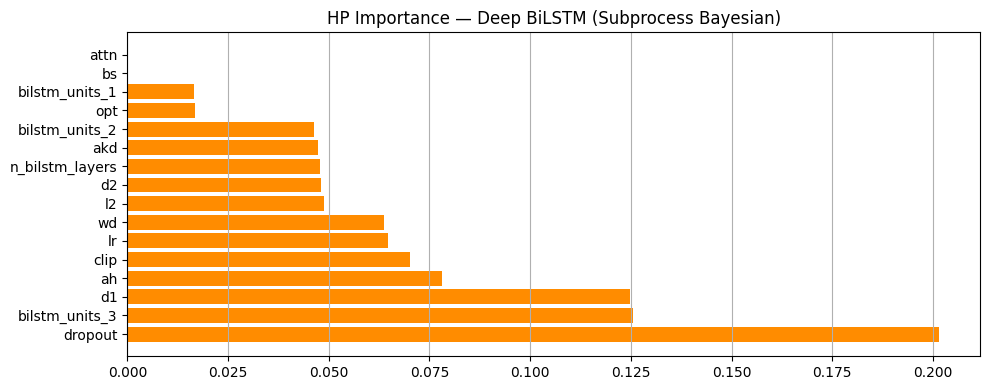


  Best HP: {'bilstm_units': [64, 64, 16], 'n_bilstm_layers': 3, 'dense_units': [32, 32], 'dropout': 0.4292063759215059, 'recurrent_dropout': 0.0, 'l2_reg': 0.0001, 'lr': 0.005101039893789344, 'batch_size': 256, 'clipnorm': 2.0, 'optimizer': 'rmsprop', 'weight_decay': 0.0, 'use_attention': False, 'attn_heads': 8, 'attn_key_dim': 16, 'epochs': 300, 'patience_es': 30, 'patience_lr': 10, 'lr_factor': 0.5, 'min_lr': 1e-07}
  Best trial — FD003: 15.464  FD004: 25.855  combined: 0.764


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# Deep BiLSTM — SNIPPET 5: RUN SEARCH
# MODIFIED: baselines extracted from all_results (Phase 0) and passed to the
# search function. FD001/FD002 baselines stored for Snippet 6 comparison table
# but NOT used in the search objective.
# ══════════════════════════════════════════════════════════════════════════════

# Extract FD003 + FD004 baselines from Phase 0 — required by objective
baselines = {
    'FD003': all_results['FD003']['rmse'],
    'FD004': all_results['FD004']['rmse'],
}

print(f"  Baselines entering search:")
print(f"    FD001: {all_results['FD001']['rmse']:.3f}  "
      f"FD002: {all_results['FD002']['rmse']:.3f}  "
      f"(not used in objective — for reference only)")
print(f"    FD003: {baselines['FD003']:.3f}  "
      f"FD004: {baselines['FD004']:.3f}  ← search target")

best_hp_bilstm, rs_bilstm, bo_bilstm = bilstm_combined_search(
    n_random=20, n_bayes=5, top_n=5,
    baselines=baselines,
    epochs_search=40)


██████████████████████████████████████████████████
  Deep BiLSTM | FD001
██████████████████████████████████████████████████


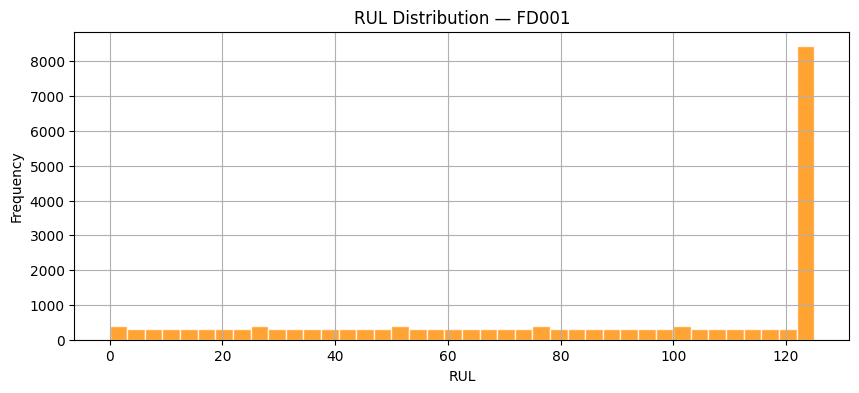

  Train:(13361, 40, 25) Val:(3270, 40, 25) Test:(100, 40, 25)
  HP: units=[64, 64, 16] dense=[32, 32] dr=0.43 lr=5.1e-03 bs=256 attn=False

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0025505200028419495.

Epoch 33: ReduceLROnPlateau reducing learning rate to 0.0012752600014209747.

Epoch 52: ReduceLROnPlateau reducing learning rate to 0.0006376300007104874.

Epoch 62: ReduceLROnPlateau reducing learning rate to 0.0003188150003552437.

Epoch 72: ReduceLROnPlateau reducing learning rate to 0.00015940750017762184.

  Val  ↓
  Deep BiLSTM                                RMSE=12.378  MAE=9.855  NASA=6870.6
  Test ↓
  Deep BiLSTM                                RMSE=14.525  MAE=10.639  NASA=325.2
  vs Paper: 13.65  →  +0.875


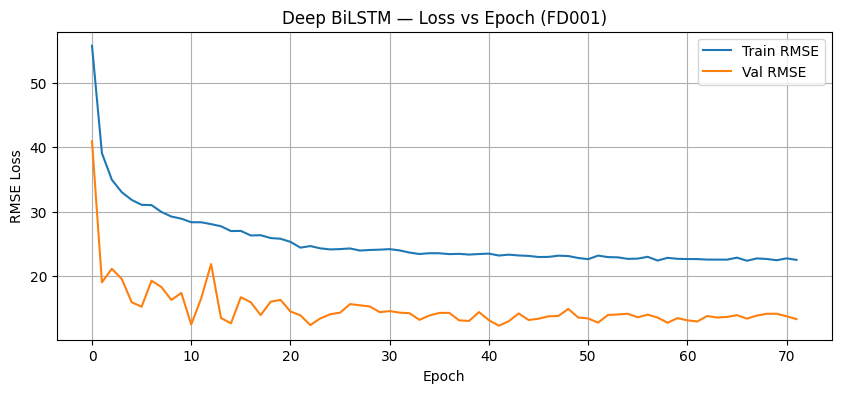

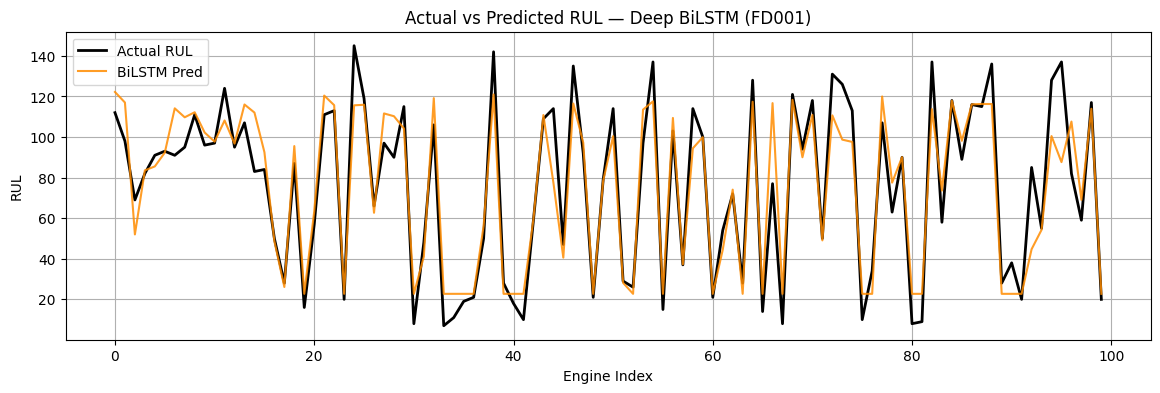

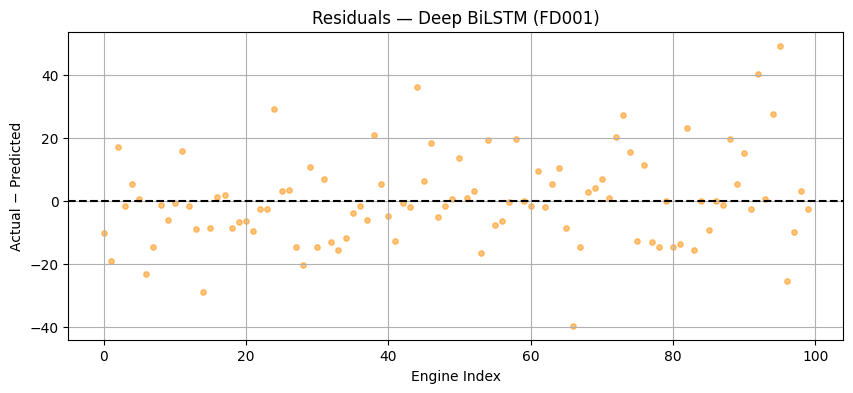


██████████████████████████████████████████████████
  Deep BiLSTM | FD002
██████████████████████████████████████████████████


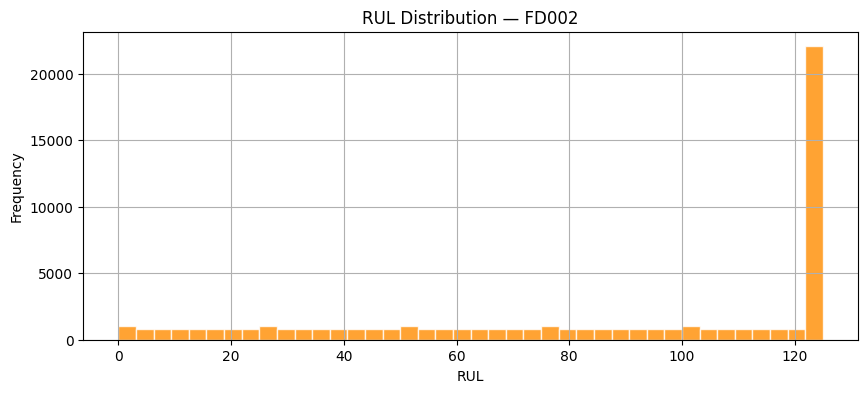

  Train:(35144, 40, 25) Val:(8215, 40, 25) Test:(259, 40, 25)
  HP: units=[64, 64, 16] dense=[32, 32] dr=0.43 lr=5.1e-03 bs=256 attn=False

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0025505200028419495.

Epoch 31: ReduceLROnPlateau reducing learning rate to 0.0012752600014209747.

Epoch 41: ReduceLROnPlateau reducing learning rate to 0.0006376300007104874.

  Val  ↓
  Deep BiLSTM                                RMSE=24.677  MAE=19.859  NASA=117795.5
  Test ↓
  Deep BiLSTM                                RMSE=35.401  MAE=26.969  NASA=32371.8
  vs Paper: 23.18  →  +12.221


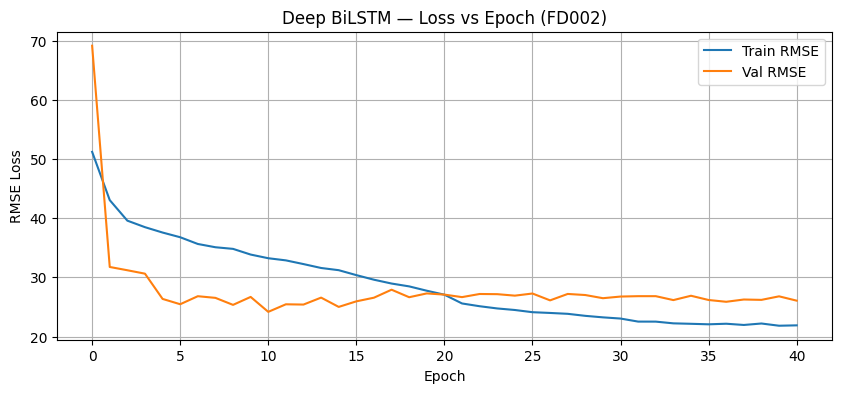

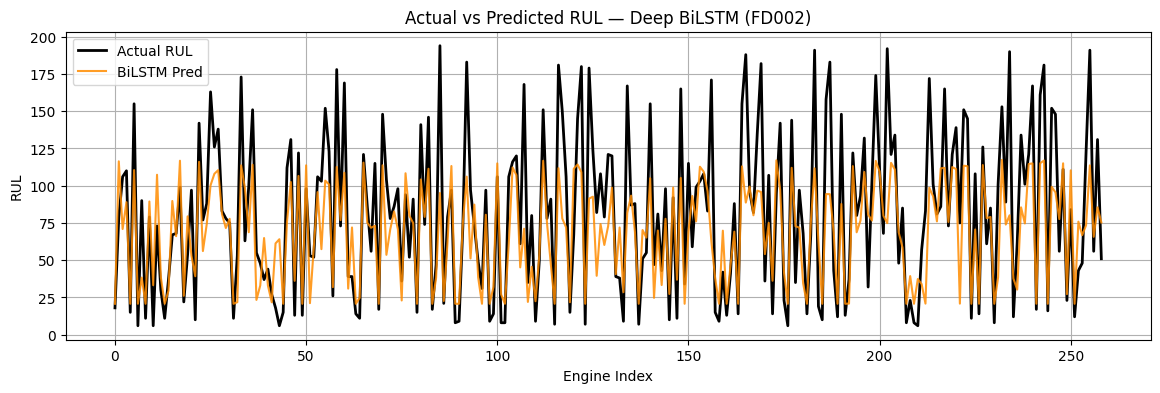

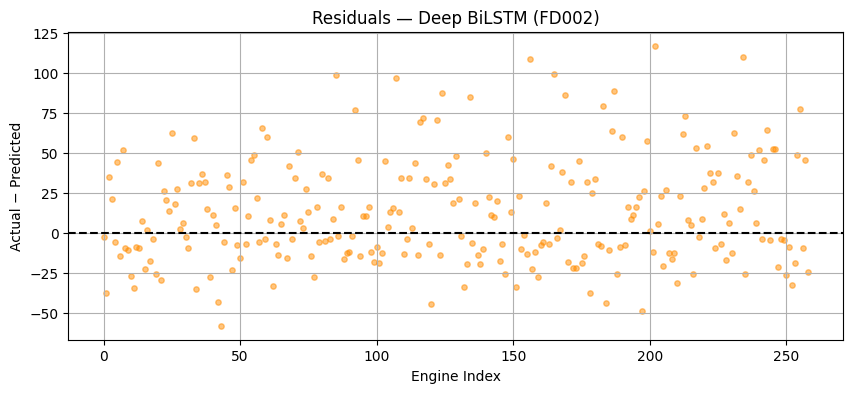


██████████████████████████████████████████████████
  Deep BiLSTM | FD003
██████████████████████████████████████████████████


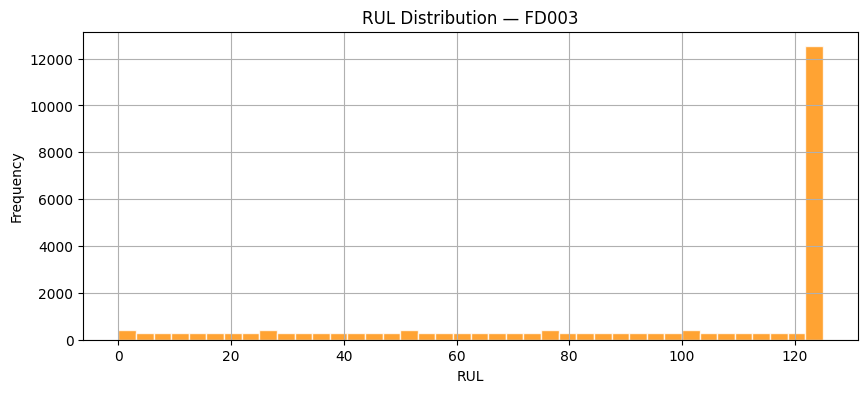

  Train:(16812, 40, 25) Val:(3908, 40, 25) Test:(100, 40, 25)
  HP: units=[64, 64, 16] dense=[32, 32] dr=0.43 lr=5.1e-03 bs=256 attn=False

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0025505200028419495.

Epoch 50: ReduceLROnPlateau reducing learning rate to 0.0012752600014209747.

Epoch 60: ReduceLROnPlateau reducing learning rate to 0.0006376300007104874.

Epoch 70: ReduceLROnPlateau reducing learning rate to 0.0003188150003552437.

  Val  ↓
  Deep BiLSTM                                RMSE=12.014  MAE=8.959  NASA=9527.4
  Test ↓
  Deep BiLSTM                                RMSE=15.819  MAE=12.777  NASA=394.9
  vs Paper: 13.74  →  +2.079


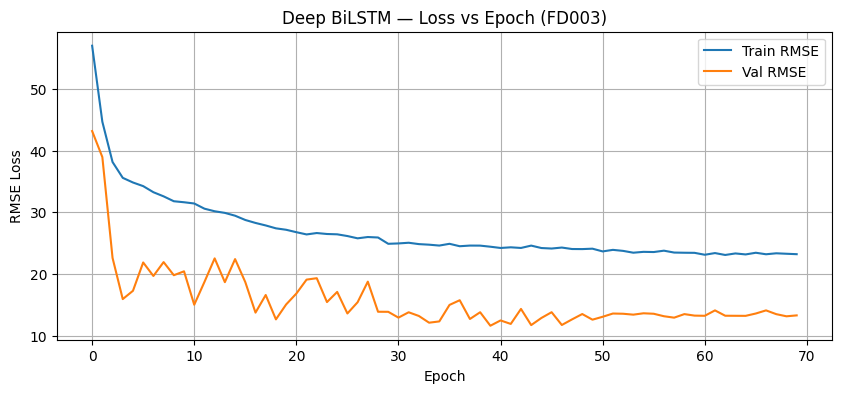

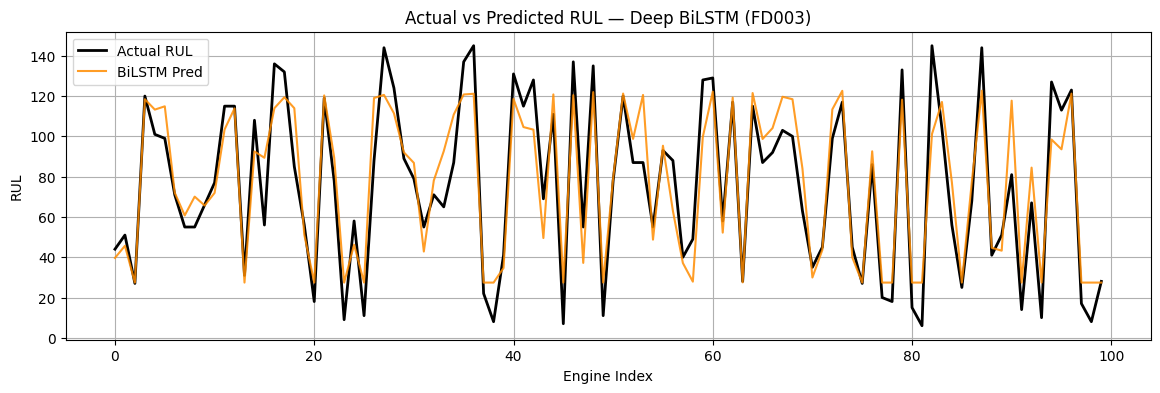

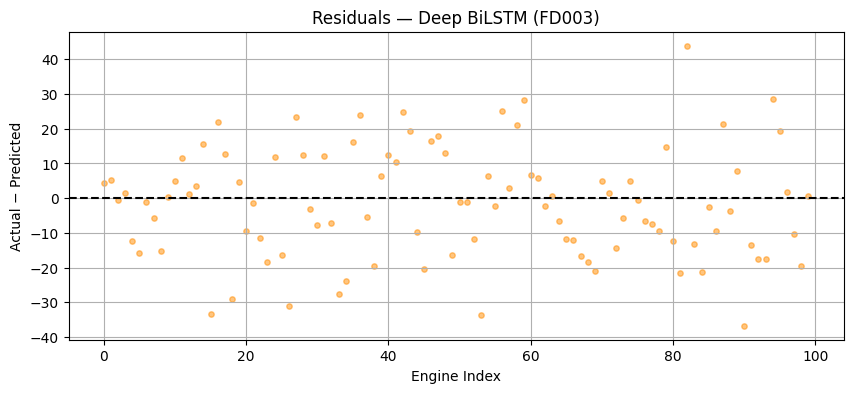


██████████████████████████████████████████████████
  Deep BiLSTM | FD004
██████████████████████████████████████████████████


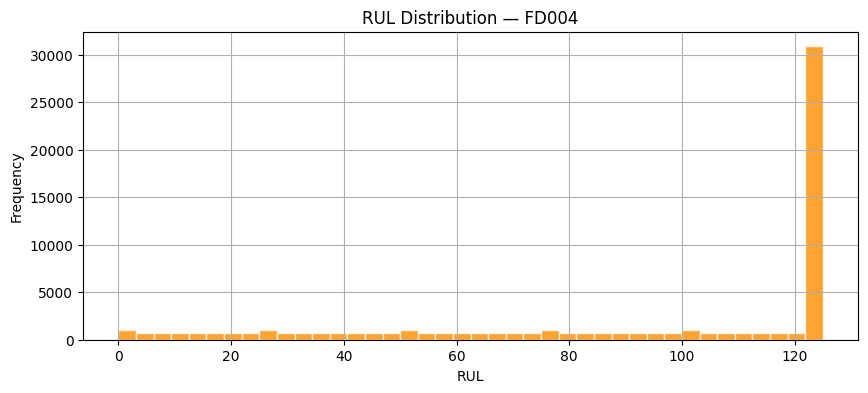

  Train:(41334, 40, 25) Val:(9955, 40, 25) Test:(248, 40, 25)
  HP: units=[64, 64, 16] dense=[32, 32] dr=0.43 lr=5.1e-03 bs=256 attn=False

Epoch 40: ReduceLROnPlateau reducing learning rate to 0.0025505200028419495.

Epoch 51: ReduceLROnPlateau reducing learning rate to 0.0012752600014209747.

Epoch 61: ReduceLROnPlateau reducing learning rate to 0.0006376300007104874.

Epoch 71: ReduceLROnPlateau reducing learning rate to 0.0003188150003552437.

  Val  ↓
  Deep BiLSTM                                RMSE=24.692  MAE=20.716  NASA=193172.2
  Test ↓
  Deep BiLSTM                                RMSE=35.247  MAE=29.145  NASA=12186.4
  vs Paper: 24.86  →  +10.387


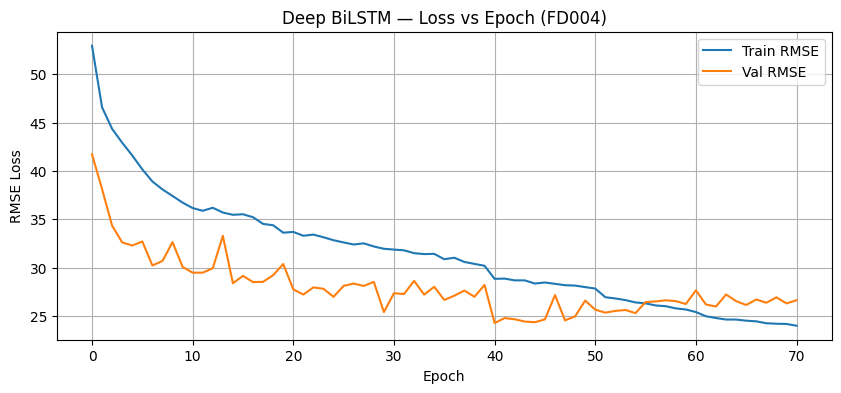

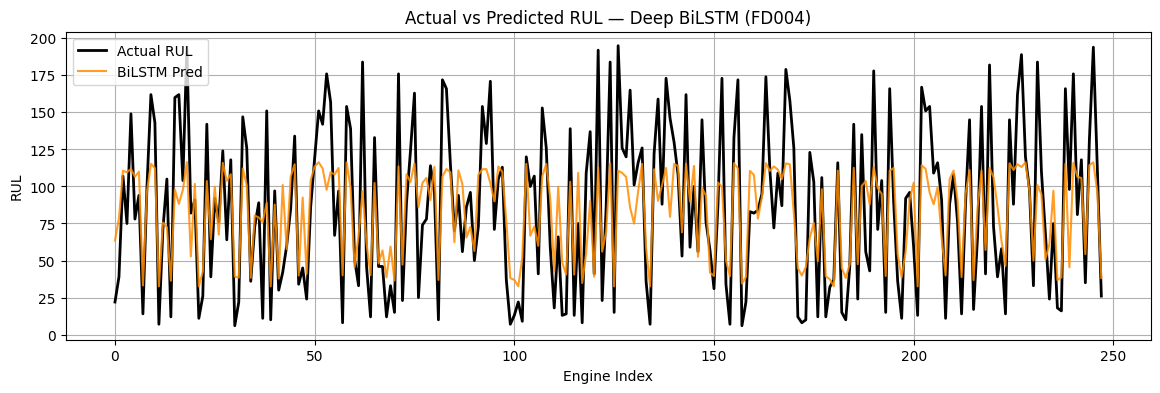

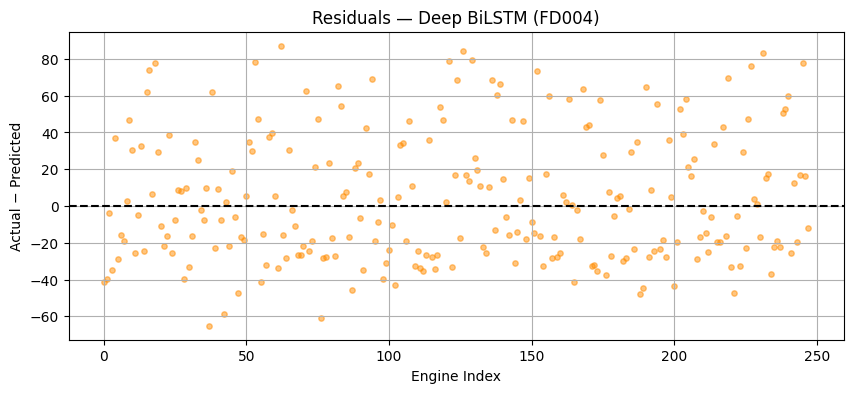


══════════════════════════════════════════════════════════════════════
  DEEP BiLSTM — OPTIMIZED RESULTS
══════════════════════════════════════════════════════════════════════
  DS             RMSE    vs Baseline   vs Paper    rel %
  ──────── ────────── ────────────── ────────── ────────
  FD001        14.525          +0.284      +0.875    +2.0%
  FD002        35.401          +4.424     +12.221   +14.3%
  FD003        15.819          -1.098      +2.079    -6.5%
  FD004        35.247          +2.430     +10.387    +7.4%

  Average RMSE — Baseline: 23.738  Optimized: 25.248  (+1.510)


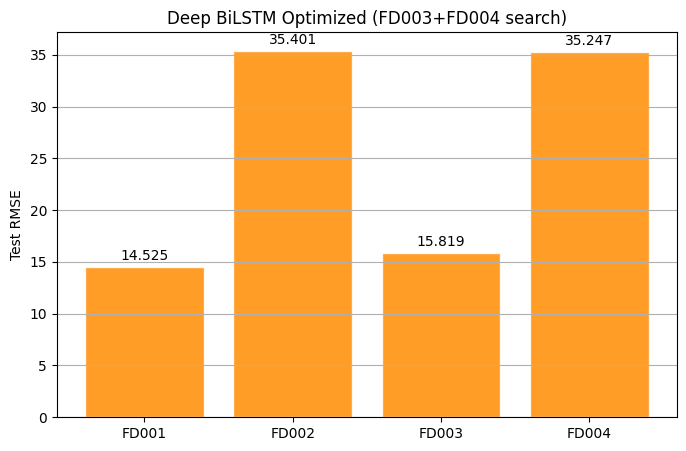

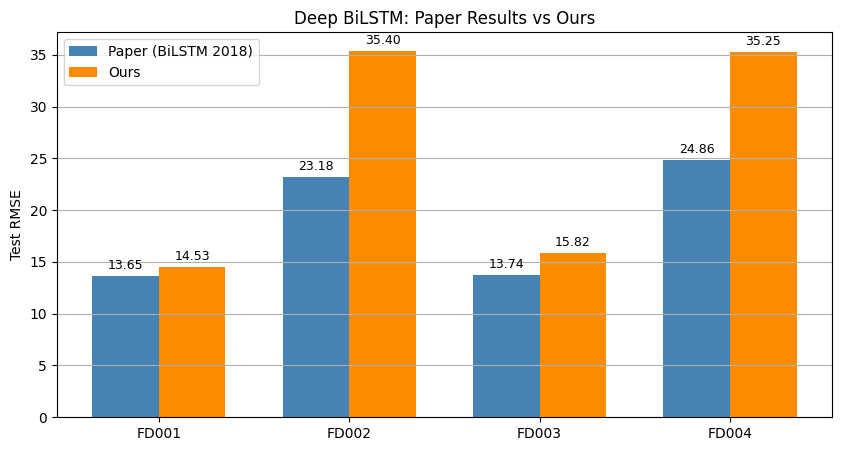


  Predictions available for ensemble:
    FD001: test_preds.shape=(100,)  [min=22.7  max=122.2  mean=75.4]
    FD002: test_preds.shape=(259,)  [min=20.7  max=117.3  mean=68.3]
    FD003: test_preds.shape=(100,)  [min=27.4  max=122.7  mean=77.0]
    FD004: test_preds.shape=(248,)  [min=32.6  max=116.4  mean=82.5]

  Compatible with DATCN, DAST, BiLSTM, and TCN predictions for weighted ensemble.


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Deep BiLSTM — SNIPPET 6: RETRAIN BEST HP ON ALL 4 DATASETS
# MODIFIED: added rel% column and avg comparison line to results table.
# ══════════════════════════════════════════════════════════════════════════════
optimized_bilstm = {}

for dataset in DATASETS:
    print(f"\n{'█'*50}\n  Deep BiLSTM | {dataset}\n{'█'*50}")
    np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

    try:
        result = train_and_evaluate(dataset, best_hp_bilstm, show_plots=True)
        optimized_bilstm[dataset] = {
            'rmse'      : result['rmse'],
            'mae'       : result['mae'],
            'mse'       : result['mse'],
            'nasa'      : result['nasa'],
            'test_preds': result['test_preds'],
        }
        del result

    finally:
        tf.keras.backend.clear_session()
        gc.collect(); gc.collect()
        _trim_ram()

print(f"\n{'═'*70}")
print(f"  DEEP BiLSTM — OPTIMIZED RESULTS")
print(f"{'═'*70}")
print(f"  {'DS':<8} {'RMSE':>10} {'vs Baseline':>14} {'vs Paper':>10} {'rel %':>8}")
print(f"  {'':─<8} {'':─>10} {'':─>14} {'':─>10} {'':─>8}")
for ds in DATASETS:
    o    = optimized_bilstm[ds]['rmse']
    b    = all_results[ds]['rmse']
    pap  = PAPER_RESULTS.get(ds, 0)
    diff = o - b
    pct  = (diff / b) * 100
    print(f"  {ds:<8} {o:>10.3f}  {diff:>+14.3f}  {o-pap:>+10.3f} {pct:>+7.1f}%")

avg_opt  = np.mean([optimized_bilstm[ds]['rmse'] for ds in DATASETS])
avg_base = np.mean([all_results[ds]['rmse']       for ds in DATASETS])
print(f"\n  Average RMSE — Baseline: {avg_base:.3f}  "
      f"Optimized: {avg_opt:.3f}  ({avg_opt-avg_base:+.3f})")
plot_rmse_bar(optimized_bilstm, 'Deep BiLSTM Optimized (FD003+FD004 search)')
plot_baseline_comparison(PAPER_RESULTS, optimized_bilstm)

print("\n  Predictions available for ensemble:")
for ds in DATASETS:
    tp = optimized_bilstm[ds]['test_preds']
    print(f"    {ds}: test_preds.shape={tp.shape}  "
          f"[min={tp.min():.1f}  max={tp.max():.1f}  mean={tp.mean():.1f}]")
print("\n  Compatible with DATCN, DAST, BiLSTM, and TCN predictions for weighted ensemble.")